# Depth-dependent gradients of inhibitory neurons
Morphoelectric properties of inhibitory neurons shift gradually with cortical depth.

In [1]:
# Load project-specific library
import decoupling

# Load other required libraries
import os
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from sklearn.metrics import adjusted_rand_score

# Define global matplotlib settings
plt.rcParams.update({
    "font.family": "Arial",
})

# Set random seed
seed = decoupling.set_seed(0)

# Set path to data
data_path = "../data/rat_bc/processed/"

Random seed 0 has been set.


In [2]:
# Read metadata 
metadata = pd.read_csv(
    os.path.join(data_path, "../bc_metadata.csv"), 
    index_col="neuron_id",
)

# Read morphological features 
morph_features = pd.read_csv(
    os.path.join(data_path, "bc_morph_features.csv"), 
    index_col="neuron_id",
).dropna()

# Read electrophysiological features 
ephys_features = pd.read_csv(
    os.path.join(data_path, "bc_ephys_features.csv"), 
    index_col="neuron_id",
).dropna()

# Preprocess morphoelectric features
X = decoupling.align_and_preprocess_features(
    Morph=morph_features, 
    Ephys=ephys_features, 
)

# Read consolidated morphoelectric features 
consolidated_features = pd.read_csv(
    os.path.join(data_path, "bc_consolidated_features.csv"), 
    index_col="neuron_id",
).dropna()

# Z-score consolidated morphoelectric features
zscored_consolidated_features = zscore(
    consolidated_features,
)

## Calculation of the me-diversity space 
The me-diversity space of inhibitory neurons in the cortical column corresponds to a low-dimensional embedding that is unfolded along the cortical depth dimension.

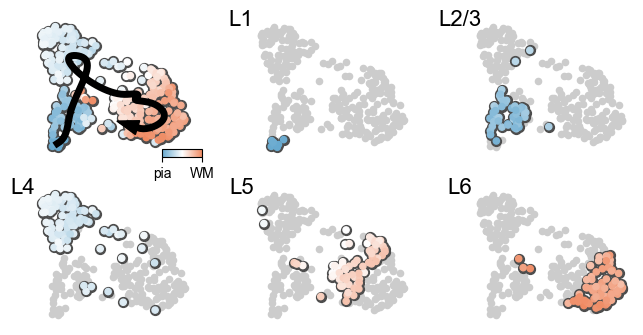

In [3]:
# Get soma depth and cortical layers
soma_depth = consolidated_features.loc[X.index, "soma_depth"]
layers = metadata.loc[X.index, "layer"]

# Calculate raw embedding via UMAP algorithm
embedding = umap.UMAP(
    n_components=2, 
    n_neighbors=50, 
    min_dist=0.2, 
    metric="cosine", 
    random_state=seed,
)
X_embedding = embedding.fit_transform(X)

# Plot raw embedding by layers
fig, ax = decoupling.plot_embedding_by_layer(
        embedding=X_embedding,
        feature=soma_depth,
        layers=layers,
        cbar_labels=["pia", "WM"],
        show_trend=True,
    )
plt.show()

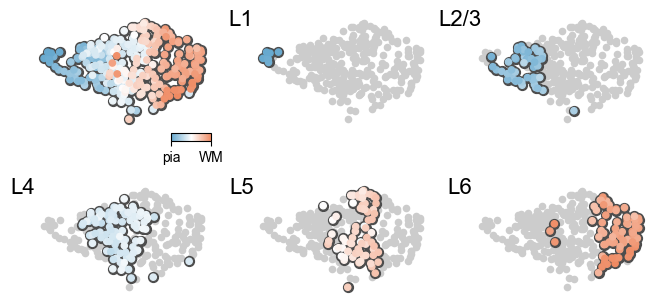

In [4]:
# Calculate the me-diversity space by unfolding the raw embedding 
X_embedding = decoupling.create_embedding(
    X=X, 
    soma_depth=soma_depth, 
    seed=seed,
    )

# Plot the me-diversity space by layers
fig, ax = decoupling.plot_embedding_by_layer(
        embedding=X_embedding,
        feature=soma_depth,
        layers=layers,
        cbar_labels=["pia", "WM"],
    )
plt.show()

## Morphoelectric cluster assignments
The me-diversity space is color-coded by me-clusters.

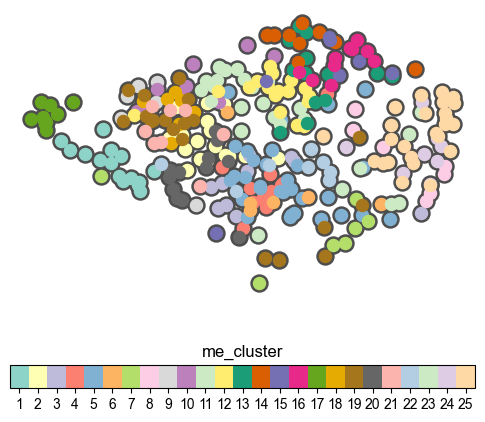

In [5]:
labels = metadata.loc[X.index, "me_cluster"]

fig, ax = decoupling.plot_embedding(X_embedding, labels)

cbar = decoupling.colorbar(fig, ax, labels)
cbar.ax.set_title("me_cluster")

plt.show()

## Laminar soma location
The me-diversity space is color-coded by cortical layers.

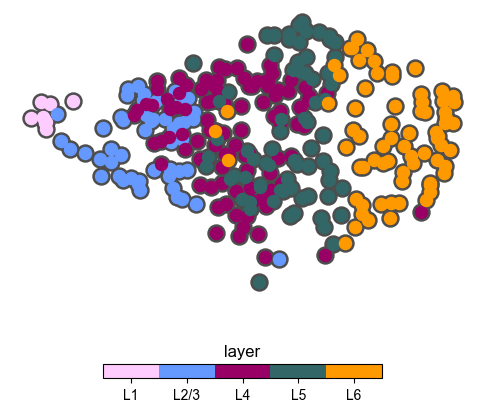

In [6]:
L1  = np.array([255, 204, 255]) / 255
L23 = np.array([102, 153, 255]) / 255
L4  = np.array([153,   0, 102]) / 255
L5  = np.array([ 51, 102, 102]) / 255
L6  = np.array([255, 153,   0]) / 255
cmap = ListedColormap([L1, L23, L4, L5, L6])

fig, ax = decoupling.plot_embedding(X_embedding, layers, cmap)

cbar = decoupling.colorbar(fig, ax, layers, shrink=0.6)
cbar.ax.set_title("layer")

plt.show()

## Morphoelectric features
The me-diversity space is color-coded by z-scored
* `soma_depth`, 
* `dendrite_volume`, 
* `axon_volume`,
* `spike_frequency`, and
* `spike_frequency_adaptation`.

By design, the gradient of `soma_depth` is aligned with the horizontal axis.

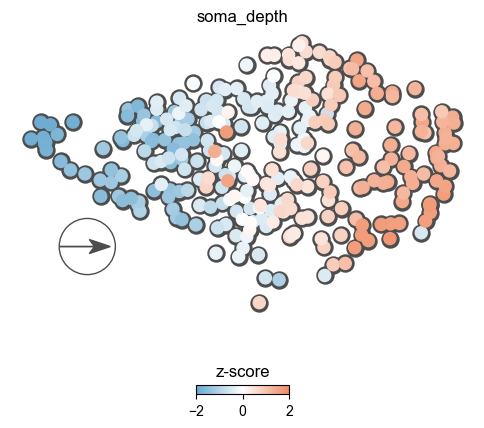

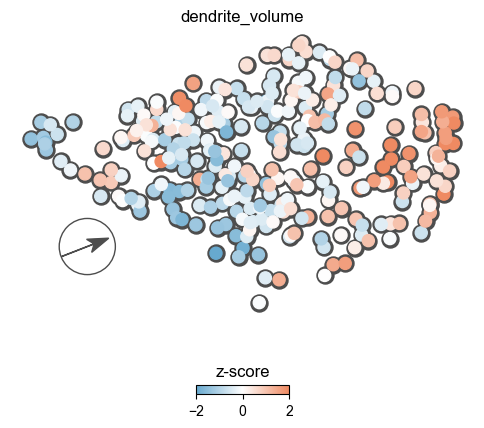

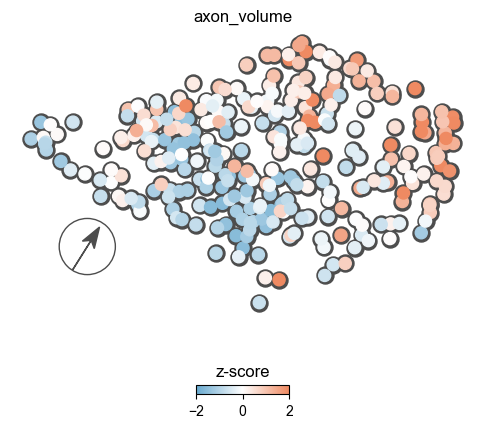

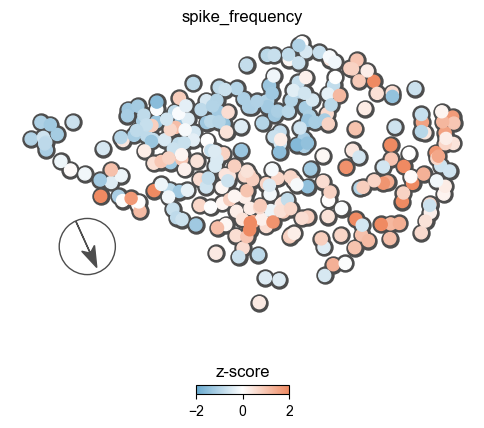

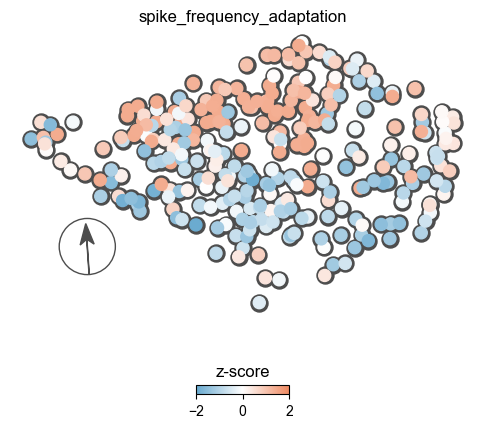

In [7]:
features = [
    "soma_depth", 
    "dendrite_volume", 
    "axon_volume",
    "spike_frequency",
    "spike_frequency_adaptation",
]

for i in features:
    
    feature = zscored_consolidated_features.loc[X.index, i]
    
    fig, ax = decoupling.plot_embedding(
        X_embedding=X_embedding, 
        color_mapping=feature, 
        vmin=-2, vmax=2,
    )

    cbar = decoupling.colorbar(fig, ax, shrink=0.2)
    cbar.ax.set_title("z-score")

    ax.set_title(i)
    
    plt.show()

## Features shift to higher values from L1 to L6
Some z-scored morphoelectric features shift on average to higher values across cortical layers.

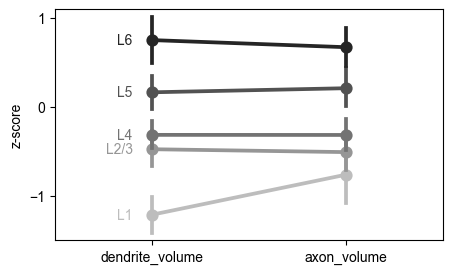

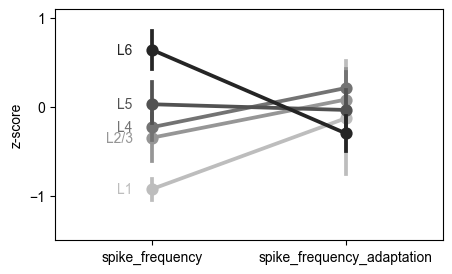

In [8]:
# Set palette
palette = {
    "L1":   "#bdbdbd", 
    "L2/3": "#969696", 
    "L4":   "#737373", 
    "L5":   "#525252", 
    "L6":   "#252525",
}

for i in range(1, len(features), 2):

    # Process paired features
    paired_features = (
        zscored_consolidated_features
        .loc[:,features[i:i+2]]
        .assign(layer=layers) 
    )
    paired_features = pd.melt(
        paired_features, 
        id_vars="layer", 
        ignore_index=False,
    )

    # Calculate y-axis position for annotations
    y_means = (
        paired_features[
            paired_features["variable"]==features[i]
        ]
        .groupby(["layer"])
        .mean(["value"])
    )

    fig, ax = plt.subplots(figsize=(5,3))

    # Plot layer means
    sns.pointplot(
        paired_features, 
        x="variable", 
        y="value", 
        hue="layer", 
        palette=palette, 
        ax=ax,
    )

    # Add annotations
    for j in y_means.index:
        ax.text(
            x=-0.1, 
            y=y_means.loc[j,:].values, 
            s=j, 
            c=palette[j], 
            ha="right", 
            va="center",
        )

    # Axis formatting
    ax.get_legend().remove()
    ax.set_ylim([-1.5, 1.1])
    ax.set_yticks([-1, 0, 1])
    ax.set_ylabel("z-score")
    ax.set_xlabel("")

    plt.show()

## Assessing me-clusters by depth-independent morphoelectric variations
Morphoelectric features of morphoelectric class assignments (me-clusters) are categorized by Groups I-IIIa/b.

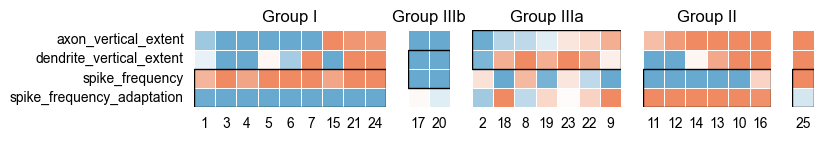

In [9]:
# Select features to be analyzed
features = [
    "axon_vertical_extent",
    "dendrite_vertical_extent", 
    "spike_frequency",
    "spike_frequency_adaptation",
]

# Calculate cluster-averaged features
cluster_means = (
    zscored_consolidated_features[features]
    .groupby([metadata.loc[X.index, "me_cluster"]])
    .mean(numeric_only=True) 
)

# Sort me-clusters
cluster_means = cluster_means.transpose()
cluster_means = cluster_means[[
     1,  3,  4,  5,  6,  7, 15, 21, 24, # Group I
    17, 20,                             # Group IIIb
     2, 18,  8, 19, 23, 22,  9,         # Group IIIa
    11, 12, 14, 13, 10, 16,             # Group II
    25,                                 # rest
]]
cluster_means.columns = [int(i) for i in cluster_means.columns]

# Set group labels
group_labels = ["Group I", "Group IIIb", "Group IIIa", "Group II", ""]

# Set number of met-cluster per group
n_classes_per_group = [9, 2, 7, 6, 1]

# Define an index to slice features matrix
idx = np.cumsum([0] + n_classes_per_group)

# Set colormap
cmap = decoupling.utils.default_colormap()

# Plot me-clusters
fig, axs = plt.subplots(
    nrows=1, ncols=5, figsize=(8,1), 
    gridspec_kw={"width_ratios": n_classes_per_group},
)

for i, j in zip(range(len(n_classes_per_group)), [2, 1, 0, 2, 2]):
    
    # Plot heatmap
    sns.heatmap(
        cluster_means.iloc[:,idx[i]:idx[i+1]], 
        vmin=-0.5, 
        vmax=0.5, 
        linewidth=0.5, 
        cmap=cmap, 
        cbar=False, 
        yticklabels=(i == 0), 
        ax=axs[i],
    )
    
    # Add annotations
    axs[i].add_patch(
        Rectangle(
            xy=(0, j), 
            width=n_classes_per_group[i], 
            height=2, 
            fill=False, 
            edgecolor="black", 
            lw=1,
        )
    )

    # Axis formatting
    axs[i].set_xlabel("")
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=0)
    axs[i].tick_params(left=False, bottom=False)
    axs[i].set_title(group_labels[i])

plt.show()

Define a schema that uses relative (z-scored) morphoelectric features to assign inhibitory neurons to depth-independent groups.

In [10]:
schema = {
        "Group I": {
            "spike_frequency": (">", 0.15),
            "spike_frequency_adaptation": ("<", -0.35)
        },
        "Group IIIb": {
            "spike_frequency": ("<", -0.5),
            "dendrite_vertical_extent": ("<", -1)
        },
        "Group IIIa": {
            "axon_vertical_extent": (
                "<linear", 
                "dendrite_vertical_extent", 
                (0.15, 0.35),
            )
        },
        "Group II": {
            "spike_frequency": (
                "<linear", 
                "spike_frequency_adaptation", 
                (3, 0.05),
            )
        }
    }

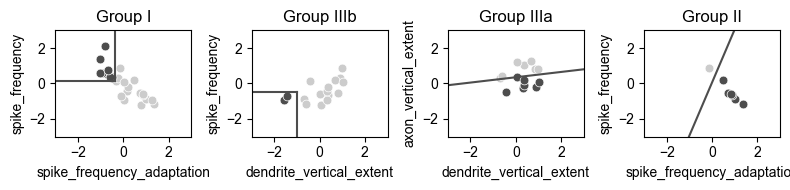

In [11]:
# Average features by cluster
cluster_means = (
    zscored_consolidated_features[features]
    .groupby([metadata.loc[X.index, "me_cluster"]])
    .mean(numeric_only=True) 
)

# Plot decoupling schema
fig, axs = decoupling.plot_decoupling_schema(
    cluster_means=cluster_means, 
    schema=schema,
)

plt.show()


## Grouping morphoelectric variations along the vertical axis of the me-diversity space
* Isolation of morphoelectric variations that are independent of cortical depth from their gradual shifts with depth.
* The isolated variability in spiking frequency and adaptation, as well as in dendrite and axon size, structure the me-diversity space.

In [12]:
# Set hierarchical model and predict broad depth-dependent clusters
model = decoupling.HierarchicalClustering()
depth_dependent_clusters = model.fit_predict(
    morph_features, 
    ephys_features,
)

..cutHeight not given, setting it to 34.8152510720541  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 36.787667128880024  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 38.18382771000671  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 49.11892818590288  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 33.614500533093064  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 35.561033736563346  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 38.5308776430549  ===>  99% of the (truncated) height range in dendro.
..cutHeight not given, setting it to 59.4970736798387  ===>  99% of the (truncated) height range in dendro.


In [13]:
# Set decoupling model
model = decoupling.Decoupling(
    schema=schema,
)

# Predict depth-independent groups
labels = model.fit_predict(
    features = zscored_consolidated_features,
    local_grouping = depth_dependent_clusters,
)

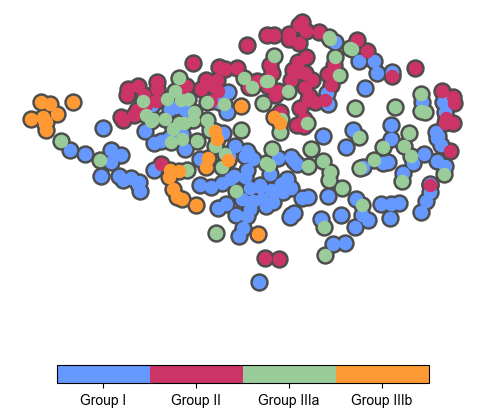

In [14]:
Group_I    = np.array([[102, 153, 255]]) / 255
Group_II   = np.array([[204,  51, 102]]) / 255
Group_IIIa = np.array([[153, 204, 153]]) / 255
Group_IIIb = np.array([[255, 153,  51]]) / 255
cmap = ListedColormap([Group_I, Group_II, Group_IIIa, Group_IIIb])

fig, ax = decoupling.plot_embedding(X_embedding, labels, cmap)
cbar = decoupling.colorbar(fig, ax, labels, shrink=0.8)

plt.show()

In [15]:
# Comparison to determine whether `labels` and the reported results are identical. 
# A score of 1 means a perfect match between clusterings.
adjusted_rand_score(
    labels, metadata.loc[X.index, "pred_mol_id"],
)

1.0

## Characterization of Groups I-IIIa/b
Overall distribution of morphoelectric features for each group.

In [16]:
# Select features to be analyzed
features = [
    "soma_depth",
    "axon_vertical_extent",
    "dendrite_vertical_extent", 
    "spike_frequency",
    "spike_frequency_adaptation",
]

# Add labels to features
melted_features = zscored_consolidated_features[features].copy()
melted_features["layer"] = metadata.loc[X.index, "layer"]
melted_features["cluster"] = labels
melted_features["cluster2"] = np.where(
    np.isin(labels, ["Group IIIa", "Group IIIb"]), 
    "Group III", 
    labels,
)

# Melt features
melted_features = (
    melted_features
    .reset_index()
    .melt(
        var_name="feature", 
        value_name="value",
        id_vars=[
            "neuron_id", 
            "soma_depth", 
            "layer", 
            "cluster", 
            "cluster2",
        ],
    )
)

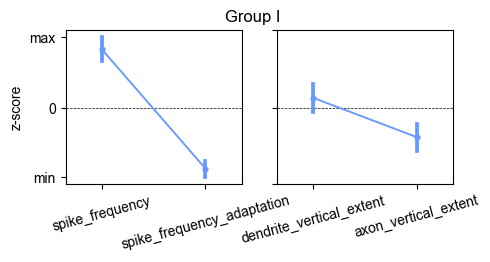

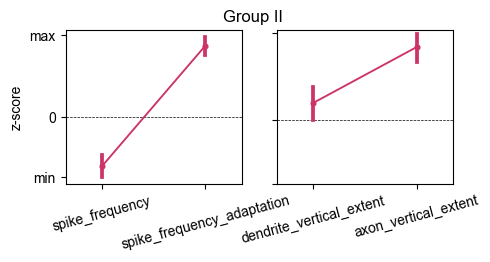

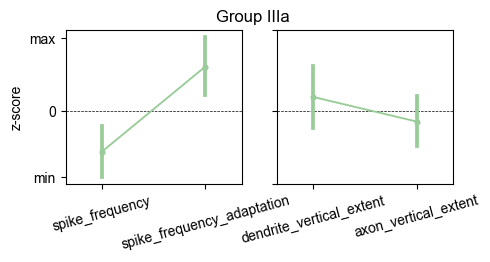

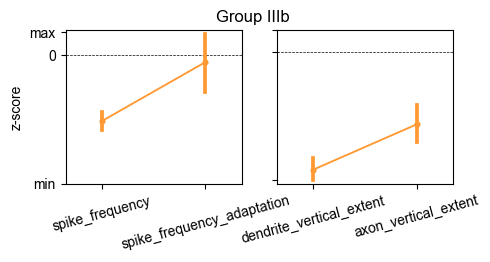

In [17]:
# Set group labels to be analyzed
unique_labels = np.unique(labels)

for i in range(len(unique_labels)):
    
    # Set name of current grouping
    cluster_id = unique_labels[i]
    
    # Subset features
    features_cluster = melted_features[
        melted_features["cluster"]==cluster_id
    ]
    
    # ---------------------------------------------------------------------
    # Plot feature pairs by current grouping
    # ---------------------------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(5, 2))
    fig.suptitle(cluster_id)

    # Feature groupings for the two panels
    feature_groups = [(2, 3), (1, 0)]

    # Global min / max for y-axis ticks
    y_bounds = (
        features_cluster
        .groupby(["cluster", "feature"])["value"]
        .agg(
            mean="mean", 
            ci_95=lambda x: 1.96 * x.std(ddof=1) / np.sqrt(len(x)),
        )
        .reset_index()
        .assign(
            lower=lambda d: d["mean"] - d["ci_95"],
            upper=lambda d: d["mean"] + d["ci_95"],
        )
        .groupby("cluster")
        .agg(min_val=("lower", "min"), max_val=("upper", "max"))
    )

    for ax, feat_idx in zip(axs, feature_groups):

        # Set feature order
        feature_order = (
            features_cluster["feature"]
            .unique()[list(feat_idx)]
        )

        # Plot current features
        sns.pointplot(
            features_cluster[
               features_cluster["feature"].isin(feature_order)
            ],
            x="feature",
            y="value",
            hue="cluster",
            order=feature_order,
            scale=0.5,
            palette={cluster_id: cmap(i)},
            ax=ax,
        )
        
        # -----------------------------------------------------------------
        # Axis formatting
        # -----------------------------------------------------------------
        bounds = y_bounds.loc[cluster_id]
        lims = np.sort([bounds["min_val"], 0, bounds["max_val"]])
        ax.set_yticks(lims)
        ax.set_yticklabels([""] * len(lims))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
        ax.set_xlim(-0.35, 1.35)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if feat_idx == (2, 3):
            ax.set_ylabel("z-score")
            ax.set_yticklabels(["min", "0", "max"])

        ax.axhline(0, linestyle="--", linewidth=0.5, color="black", zorder=0.5)
        ax.legend_.remove()

    plt.show()


## Depth-independent groupings
Morphoelectric features separate inhibitory neurons into Groups I-III at any cortical depth.

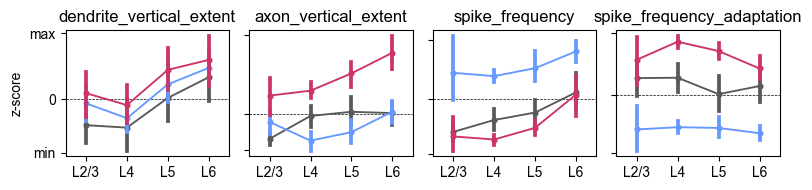

In [18]:
# Set features to be analyzed
features = [
    "dendrite_vertical_extent",
    "axon_vertical_extent",
    "spike_frequency", 
    "spike_frequency_adaptation", 
]

# Remove L1 from current analysis
melted_features = melted_features[
    melted_features["layer"] != "L1"
]

# Set palette
palette = {
    "Group I": Group_I,
    "Group II": Group_II,
    "Group III": np.array([88, 89, 91])/255
}

# -------------------------------------------------------------------------
# Plot features by grouping across layers
# -------------------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8,2))

# Global min / max for y-axis ticks
y_bounds = (
    melted_features
    .groupby(["cluster2", "feature", "layer"])["value"]
    .agg(
        mean="mean",
        ci_95=lambda x: 1.96 * x.std(ddof=1) / np.sqrt(len(x)),
        )
    .reset_index()
    .assign(
        lower=lambda d: d["mean"] - d["ci_95"],
        upper=lambda d: d["mean"] + d["ci_95"],
    )
    .groupby("feature")
    .agg(min_val=("lower", "min"), max_val=("upper", "max"))
)

for (i, ax) in zip(features, axs):
    
    # Plot current feature
    sns.pointplot(
        melted_features[
            melted_features["feature"] == i
        ],
        x="layer", 
        y="value", 
        hue="cluster2", 
        palette=palette, 
        scale=0.5, 
        ax=ax,
    )
          
    # ---------------------------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------------------------
    bounds = y_bounds.loc[i]
    lims = np.sort([bounds["min_val"], 0, bounds["max_val"]])
    ax.set_yticks(lims)
    ax.set_yticklabels(
        ["min", "0", "max"] if i == "dendrite_vertical_extent" else [""]*3,
    )

    ax.set_title(i)
    ax.set_xlabel("")
    ax.set_ylabel("" if i != "dendrite_vertical_extent" else "z-score")
    ax.axhline(0, linestyle="--", linewidth=0.5, c="black", zorder=0.5)

    ax.get_legend().remove()

fig.tight_layout()
plt.show()